Imports

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import logging

import joblib

In [ ]:
logging.basicConfig(
    filename='training.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logging.info(" TRAINING STARTED ")

REPRODUCIBILITY

In [ ]:
# After imports cell
import numpy as np
import random
import os

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

Load Dataset

In [ ]:
df = pd.read_csv("IoT_Modbus.csv")

print("Shape:", df.shape)
df.head()

Shape: (287194, 8)


,date,time,FC1_Read_Input_Register,FC2_Read_Discrete_Value,FC3_Read_Holding_Register,FC4_Read_Coil,label,type
0,31-Mar-19,12:36:55,53287,1463,33518,23014,0,normal
1,31-Mar-19,12:36:58,41029,55891,26004,50645,0,normal
2,31-Mar-19,12:36:58,41029,55891,26004,50645,0,normal
3,31-Mar-19,12:37:00,64661,40232,33460,44046,0,normal
4,31-Mar-19,12:37:01,64661,40232,33460,44046,0,normal


Dataset Info

In [ ]:
print(df.info())
print("\nClass Distribution:\n", df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287194 entries, 0 to 287193
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   date                       287194 non-null  object
 1   time                       287194 non-null  object
 2   FC1_Read_Input_Register    287194 non-null  int64 
 3   FC2_Read_Discrete_Value    287194 non-null  int64 
 4   FC3_Read_Holding_Register  287194 non-null  int64 
 5   FC4_Read_Coil              287194 non-null  int64 
 6   label                      287194 non-null  int64 
 7   type                       287194 non-null  object
dtypes: int64(5), object(3)
memory usage: 17.5+ MB
None

Class Distribution:
 label
0    222855
1     64339
Name: count, dtype: int64


Feature Engineering

In [ ]:
# X = df.drop('label', axis=1).copy()
# y = df['label']

# # ---- DATE ----
# X['date'] = pd.to_datetime(X['date'])
# X['year'] = X['date'].dt.year
# X['month'] = X['date'].dt.month
# X['day'] = X['date'].dt.day
# X = X.drop(columns=['date'])

# # ---- TIME ----
# X['time'] = X['time'].str.strip()
# X['time'] = pd.to_datetime(X['time'], format='%H:%M:%S')

# X['hour'] = X['time'].dt.hour
# X['minute'] = X['time'].dt.minute

# X = X.drop(columns=['time'])

# # REMOVE TYPE COMPLETELY (CRITICAL FIX)
# if 'type' in X.columns:
#     X = X.drop(columns=['type'])

# # REMOVE HIGH-LEAKAGE TIME FEATURES
# X = X.drop(columns=['year', 'month', 'day'])
X = df.drop('label', axis=1).copy()
y = df['label']

# ---- DATE ----
X['date'] = pd.to_datetime(X['date'])
X['year'] = X['date'].dt.year
X['month'] = X['date'].dt.month
X['day'] = X['date'].dt.day
X = X.drop(columns=['date'])

# ---- TIME ----
X['time'] = X['time'].str.strip()
X['time'] = pd.to_datetime(X['time'], format='%H:%M:%S')

X['hour'] = X['time'].dt.hour
X['minute'] = X['time'].dt.minute

X = X.drop(columns=['time'])

# REMOVE TYPE (leakage)
if 'type' in X.columns:
    X = X.drop(columns=['type'])

# REMOVE ALL TIME-BASED FEATURES
X = X.drop(columns=['year', 'month', 'day', 'hour', 'minute'])



/tmp/ipykernel_5173/2718452503.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X['date'] = pd.to_datetime(X['date'])


Dataset Analysis

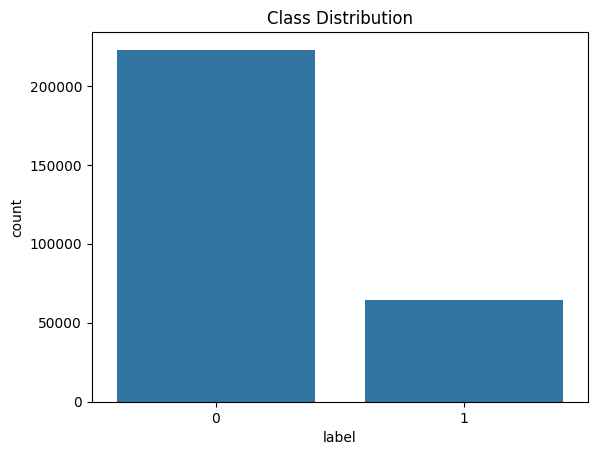

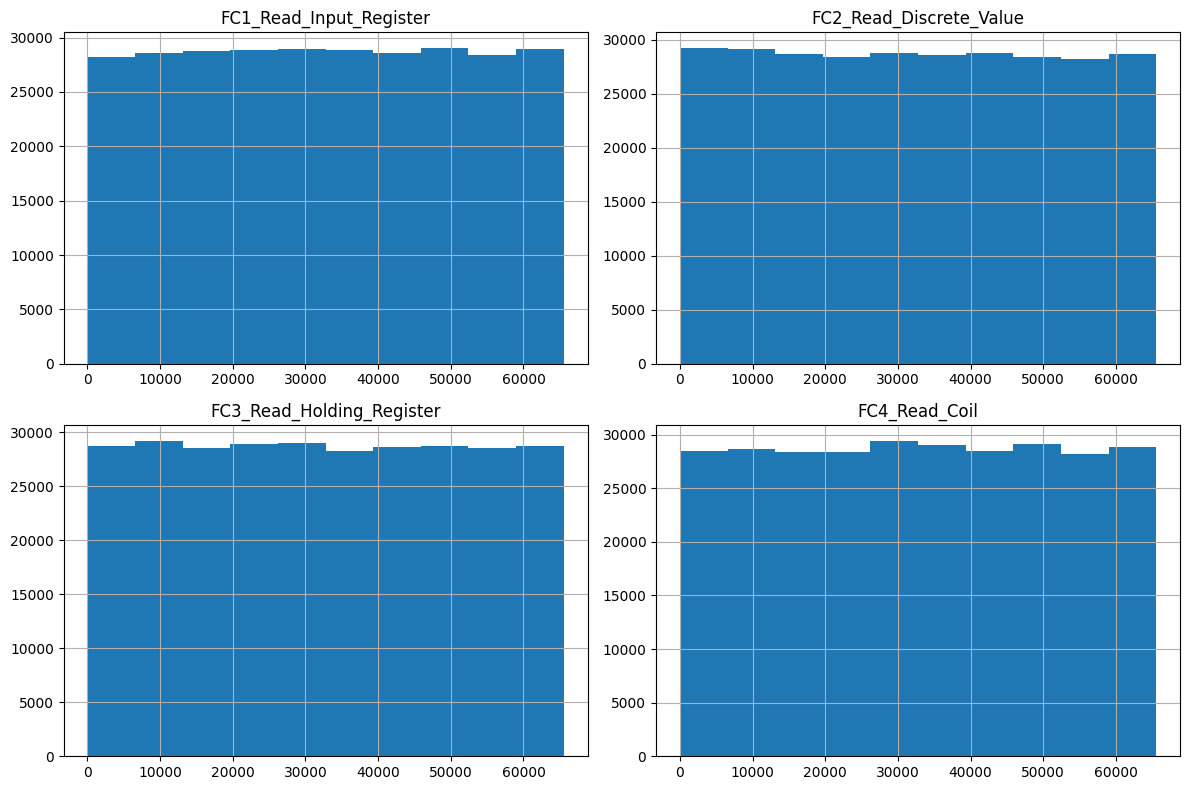

In [ ]:
# After feature engineering, before split
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

X.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

SCALE AFTER SPLIT

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

APPLY SMOTE ONLY ON TRAIN

In [ ]:
# BEFORE SMOTE
print("Before SMOTE:", np.bincount(y_train))

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

# AFTER SMOTE
print("After SMOTE:", np.bincount(y_train))

Before SMOTE: [178284  51471]
After SMOTE: [178284 178284]


## BASELINE MODELS
* Define Models

In [ ]:
from sklearn.svm import LinearSVC

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
lgbm = LGBMClassifier(random_state=42)

lr = LogisticRegression(max_iter=1000, class_weight='balanced')

svm = LinearSVC()

models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "Logistic Regression": lr,
    "SVM (Linear)": svm
}

In [ ]:
# CPU time
import time

start = time.time()
rf.fit(X_train, y_train)
end = time.time()

print("RF Training Time:", end - start)

RF Training Time: 301.74967432022095


Train & Compare Models

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

results = {}

print("===== MODEL COMPARISON =====")

for name, model in models.items():

    print(f"\nTraining {name}...")
    logging.info(f"Training started: {name}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    results[name] = {
        "Accuracy": acc,
        "F1 Score": f1,
        "Recall": recall
    }

    print(f"\n{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Recall   : {recall:.4f}")


    logging.info(f"{name} | Accuracy: {acc:.4f}, F1: {f1:.4f}, Recall: {recall:.4f}")

logging.info("===== TRAINING COMPLETED =====")

===== MODEL COMPARISON =====

Training Random Forest...

Random Forest
Accuracy : 0.9561
F1 Score : 0.9013
Recall   : 0.8938

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:56:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
Accuracy : 0.6200
F1 Score : 0.4106
Recall   : 0.5908

Training LightGBM...
[LightGBM] [Info] Number of positive: 178284, number of negative: 178284
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014769 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 356568, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM
Accuracy : 0.5245
F1 Score : 0.3715
Recall   : 0.6273

Training Logistic Regression...

Logistic Regression
Accuracy : 0.5059
F1 Score : 0.3133
Recall   : 0.5030

Training SVM (Linear)...

SVM (Linear)
Accuracy : 0.5059
F1 Score : 0.3133
Recall   : 0.5030


In [ ]:
# Probability prediction
y_probs = rf.predict_proba(X_test)[:, 1]

# Try different thresholds
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    y_temp = (y_probs > t).astype(int)
    print(f"\nThreshold {t}")
    print("F1:", f1_score(y_test, y_temp))
    print("Recall:", recall_score(y_test, y_temp))


Threshold 0.3
F1: 0.8341997264021888
Recall: 0.9477774323904259

Threshold 0.4
F1: 0.8741196530506339
Recall: 0.9163040099471558

Threshold 0.5
F1: 0.9012969711218213
Recall: 0.8937674852346907

Threshold 0.6
F1: 0.9143088771787596
Recall: 0.8764376748523469

Threshold 0.7
F1: 0.9093549056212404
Recall: 0.8517252098228163


In [ ]:
best_f1 = 0
best_threshold = 0.5

for t in thresholds:
    y_temp = (y_probs > t).astype(int)
    f1 = f1_score(y_test, y_temp)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("\nBest Threshold:", best_threshold)
y_pred_rf = (y_probs > best_threshold).astype(int)


Best Threshold: 0.6


In [ ]:
# Statistical Significance
from scipy.stats import ttest_ind
from sklearn.model_selection import cross_val_score

rf_scores = cross_val_score(rf, X, y, cv=3, scoring='f1')
xgb_scores = cross_val_score(xgb, X, y, cv=3, scoring='f1')

t_stat, p_val = ttest_ind(rf_scores, xgb_scores)

print("T-test p-value:", p_val)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:03:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:04:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:04:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


T-test p-value: 0.0007398813653894851


In [ ]:
# Scalability test
sample_sizes = [1000, 5000, 10000]

for size in sample_sizes:
    X_sample = X[:size]
    y_sample = y[:size]

    start = time.time()
    rf.fit(X_sample, y_sample)
    print(f"Size {size} → Time: {time.time() - start:.2f}s")

Size 1000 → Time: 0.18s
Size 5000 → Time: 0.18s
Size 10000 → Time: 0.22s


In [ ]:
import pandas as pd

results_df = pd.DataFrame(results).T

print("\n===== FINAL COMPARISON TABLE =====")
print(results_df)


===== FINAL COMPARISON TABLE =====
                     Accuracy  F1 Score    Recall
Random Forest        0.956145  0.901297  0.893767
XGBoost              0.620014  0.410618  0.590846
LightGBM             0.524522  0.371511  0.627293
Logistic Regression  0.505945  0.313280  0.503031
SVM (Linear)         0.505928  0.313273  0.503031


Cross Validation

In [ ]:
from sklearn.pipeline import Pipeline

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X, y, cv=kfold, scoring='f1')

    print(f"{name} CV F1: {scores.mean():.4f}")

Random Forest CV F1: 0.9246


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:20:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:20:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:20:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:20:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost CV F1: 0.0442
[LightGBM] [Info] Number of positive: 51471, number of negative: 178284
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002587 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 229755, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.224026 -> initscore=-1.242359
[LightGBM] [Info] Start training from score -1.242359


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 51471, number of negative: 178284
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008982 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 229755, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.224026 -> initscore=-1.242359
[LightGBM] [Info] Start training from score -1.242359


...

[LightGBM] [Info] Number of positive: 51471, number of negative: 178284
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002840 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 229755, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.224026 -> initscore=-1.242359
[LightGBM] [Info] Start training from score -1.242359


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 51472, number of negative: 178284
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009466 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 229756, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.224029 -> initscore=-1.242340
[LightGBM] [Info] Start training from score -1.242340


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM CV F1: 0.0022
Logistic Regression CV F1: 0.3118
SVM (Linear) CV F1: 0.0000


### DEEP LEARNING MODEL

Import DL

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

Build DL Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

dl_model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

dl_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Class weight
from sklearn.utils import class_weight
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {0: weights[0], 1: weights[1]}

Train DL Model

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = dl_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/30
8915/8915 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - accuracy: 0.6247 - loss: 0.6628 - val_accuracy: 0.0000e+00 - val_loss: 0.9868
Epoch 2/30
8915/8915 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.6250 - loss: 0.6617 - val_accuracy: 0.0000e+00 - val_loss: 0.9702
Epoch 3/30
8915/8915 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.6250 - loss: 0.6615 - val_accuracy: 0.0000e+00 - val_loss: 0.9766
Epoch 4/30
8915/8915 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - accuracy: 0.6250 - loss: 0.6615 - val_accuracy: 0.0000e+00 - val_loss: 0.9778
Epoch 5/30
8915/8915 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.6250 - loss: 0.6615 - val_accuracy: 0.0000e+00 - val_loss: 0.9694
Epoch 6/30
8915/8915 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.6250 - loss: 0.6614 - val_accuracy: 0.0000e+00 - val_loss: 0.9746
Epoch 7/30
8915/8915 ━━━━━━━━━━━━━━━━━━━━ 32s 4ms/step - accuracy: 0.6250 - loss: 0.6614 - val_accuracy: 0.0000e+00 - val_loss: 0.9609
Epoch 8/30
8915/8915 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step 

predicition

In [ ]:
y_probs = dl_model.predict(X_test)

# Lower threshold
y_pred_dl = (y_probs > 0.3).astype(int)


1795/1795 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Evaluate DL

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

dl_acc = accuracy_score(y_test, y_pred_dl)
dl_f1 = f1_score(y_test, y_pred_dl)
dl_recall = recall_score(y_test, y_pred_dl)

print("\n===== DEEP LEARNING RESULTS =====")
print(f"Accuracy : {dl_acc:.4f}")
print(f"F1 Score : {dl_f1:.4f}")
print(f"Recall   : {dl_recall:.4f}")


===== DEEP LEARNING RESULTS =====
Accuracy : 0.2240
F1 Score : 0.3661
Recall   : 1.0000


ENSEMBLE MODEL

Ensemble


In [ ]:
# Create ensemble
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('lr', lr),
        ('svm', svm)
    ],
    voting='hard'   # use hard for speed
)

# Train
ensemble.fit(X_train, y_train)

# Predict
y_pred_ens = ensemble.predict(X_test)

# Accuracy
ens_acc = accuracy_score(y_test, y_pred_ens)

# Predict using Random Forest
rf_pred = rf.predict(X_test)

# Print
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print("Ensemble Accuracy:", ens_acc)

RF Accuracy: 0.7759710301363185
Ensemble Accuracy: 0.5059454377687633


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Ensemble Evaluation

In [ ]:
ens_acc = accuracy_score(y_test, y_pred_ens)
ens_f1 = f1_score(y_test, y_pred_ens)

print("Ensemble Accuracy:", ens_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_ens))

results["Ensemble"] = (ens_acc, ens_f1)

Ensemble Accuracy: 0.5059454377687633

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.51      0.61     44571
           1       0.23      0.50      0.31     12868

    accuracy                           0.51     57439
   macro avg       0.50      0.50      0.46     57439
weighted avg       0.66      0.51      0.55     57439



CONFUSION MATRIX

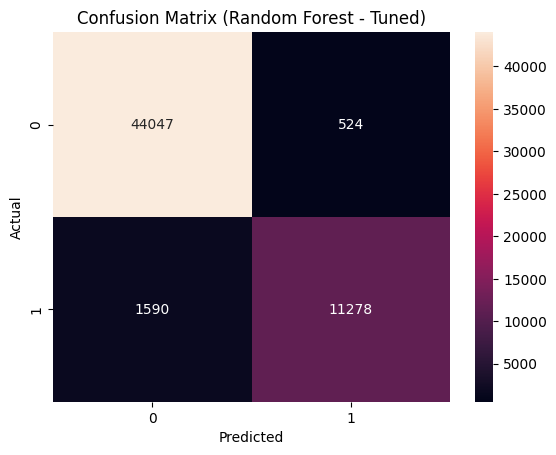

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Random Forest - Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

FEATURE IMPORTANCE

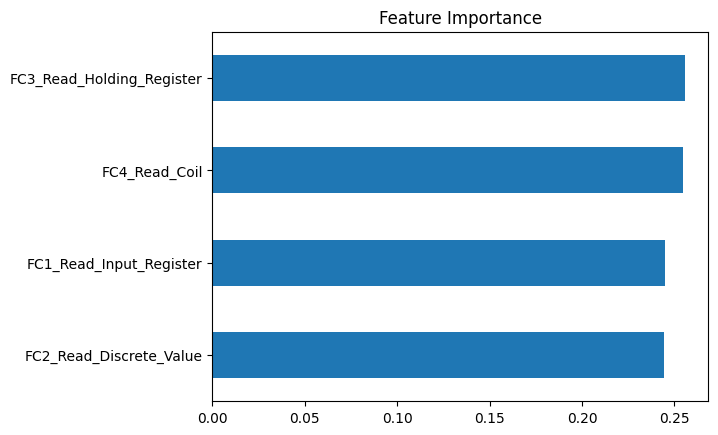

In [ ]:
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

ABLATION STUDY

In [ ]:
rf_pred = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print("Ensemble Accuracy:", ens_acc)

RF Accuracy: 0.956144779679312
Ensemble Accuracy: 0.5059454377687633


RESULTS TABLE

In [ ]:
results_df = pd.DataFrame(results, index=["Accuracy", "F1 Score"]).T
print(results_df)

                     Accuracy  F1 Score
Random Forest        0.956145  0.901297
XGBoost              0.620014  0.410618
LightGBM             0.524522  0.371511
Logistic Regression  0.505945  0.313280
SVM (Linear)         0.505928  0.313273
Ensemble             0.505945  0.313280


FINAL PIPELINE

In [ ]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

Train Final Model

In [ ]:
final_pipeline.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(random_state=42))])

Save .pkl

In [ ]:
joblib.dump(final_pipeline, "ddos_detection_model.pkl")
print("Model saved successfully!")

Model saved successfully!


Save with Features

In [ ]:
joblib.dump({
    "model": final_pipeline,
    "features": X.columns.tolist()
}, "ddos_model_bundle.pkl")

['ddos_model_bundle.pkl']